In [1]:
## Import all required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # nicer statistical plots
import anndata as ad
import scimap as sm
from scipy.spatial.distance import cdist, pdist  # pairwise distance calcs
from scipy.cluster.hierarchy import linkage, dendrogram # clustering for heatmaps

from PIL import Image # Python Imaging Library, used to load a saved image back in
import matplotlib.patches as mpatches  # used to build colored legend squares manually for voronoi

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

Running SCIMAP  2.3.5


/Users/elizabethxiu/miniforge3/envs/scimap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



✅ All libraries imported successfully.


In [2]:
## ‼️ UPDATE ‼️ this cell when doing new samples or when you want to make a change

# one h5ad path per sample -- add/remove entries here depending on how many samples you're comparing
sample_h5ads = {  # ‼️UPDATE‼️ path + name for your 2nd, 3rd, etc... sample
    '41_ST_KO':      '/Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/adata_tocombine/adata_41_ST_KO.h5ad', 
    '40_ST_KO':  '/Users/elizabethxiu/Downloads/KS_2/analysis/scimap_results/adata_tocombine/adata_40_ST_KO.h5ad',
    'BDBAT0085' : '/Users/elizabethxiu/Downloads/FOR_ELIZABETH/Tutorial/analysis/scimap_results/adata_tocombine/adata_BDBAT0085.h5ad'
}

# Column names
phenotype_col = 'phenotype' # column holding cell type labels
roi_col = 'ROI'  # column holding each sample's ORIGINAL roi assignment (Tumor1, Tumor2, Spleen, Tumor, etc -- before we combine samples below)

# ROI naming isn't consistent across samples (ex. one sample has Tumor1/Tumor2/Spleen, another just has Tumor/Spleen)
# so instead of a fixed rois_to_use list, we bucket ROIs into shared categories by keyword (case-insensitive "contains" match)
roi_keywords = {
    'Tumor':  'tumor',   # anything with "tumor" in the name (Tumor1, Tumor2, Tumor...) gets bucketed here
    'Spleen': 'spleen', # same logic
}

# Which category is this run comparing? must be one of the keys in roi_keywords above
category_to_compare = 'Tumor'  # ‼️UPDATE‼️ change to 'Spleen' to run that comparison instead

# Confirm the configuration
print(f"Samples configured: {list(sample_h5ads.keys())}")
print(f"Comparing category: {category_to_compare}")

Samples configured: ['41_ST_KO', '40_ST_KO', 'BDBAT0085']
Comparing category: Tumor


In [3]:
# Several of the commands below require inputs in pixels
# Here is a formula to convert your desired radius in um to pixels

# um to pixel conversion formula:
radius_um = 30  # the radius you want in micrometers
pixel_size_um = 0.65  # your known pixel size -- this shouldn't change

radius_px = radius_um / pixel_size_um

print(f"Radius: {radius_um} um = {radius_px:.1f} pixels")

Radius: 30 um = 46.2 pixels


In [4]:
## Extra custom configuration -- ‼️UPDATE‼️ this cell as well when doing new samples or when you want to make a change

# Spatial interaction radius (pixels)
# 70px is approx 50–100 µm depending on image resolution
interaction_radius = 76.9 ## ‼️UPDATE‼️ based on formula above -- double check pixel_size_um is the same across ALL your samples first,
                           # if it's not, this needs to be computed per sample instead of one shared value

# Where to save plots for this combined analysis (no longer tied to a single sample's working_dir now that we have several)
output_dir = '/Users/elizabethxiu/Downloads/cross_sample_analysis/plots' # ‼️UPDATE‼️

# Voronoi tissue map settings
# NOTE, voronoi_roi / foldchange_from / aggregate_roi below now need to be "sample_roi" names (sample + '_' + original ROI),
# which is built further down in the notebook -- e.g. '41_ST_KO_Tumor1' 
voronoi_roi = '41_ST_KO_Tumor1'    # which region to plot -- change to any of your sample_roi combos
voronoi_save_dir = output_dir
voronoi_filename = f'voronoi_{voronoi_roi}.png' # filename for the saved plot
voronoi_size_max = 3000      # max polygon size in pixels^2, -- higher = more filled but more edge spikes

# Foldchange settings
foldchange_from = '41_ST_KO_Tumor1'   # the reference region, all other regions in THIS run are compared TO this one
foldchange_to  = None  # None = compare against ALL other regions in this run automatically, can also set to (ex.) 'SAMPLE2_NAME_Tumor' to compare just 1 pair
foldchange_label = 'foldchange_roi' # name to store the results under inside adata1

# Spatial distance settings
distance_from = 'Tumor cells' # the cell type to measure FROM
distance_to  = [
    'neutrophils',
    'PDL1 cells',
    'PD1 cells',
    'M2 Macs',
    'M1 Macs',
    'Epithilial cells',
    'Dendritic cells',
    'CD8+ T cells',
    'CD4+ T cells',
]
# the cell types to measure TO


# Spatial aggregate settings
aggregate_roi = '41_ST_KO_Tumor1' # which region to plot for the aggregate voronoi
aggregate_radius = 46.2  # search radius in pixels -- how far to look for neighbors ## ‼️UPDATE‼️based on formula above
aggregate_purity = 80  # minimum % of neighbors that must be the same cell type to call a region "pure"
aggregate_label = 'spatial_aggregate'  # name for the new column added to adata1.obs


# Confirm the configuration
print(f"Save directory: {voronoi_save_dir}")

Save directory: /Users/elizabethxiu/Downloads/cross_sample_analysis/plots


In [5]:
# Load each sample's phenotyped adata (saved at the end of step 1) and combine into one object
# ad.concat's label= param automatically adds a new obs column recording which sample each cell came from
adata = ad.concat(
    {name: ad.read_h5ad(path) for name, path in sample_h5ads.items()},
    label='sample',       # new column: which sample each cell came from
    index_unique='-'      # appends the sample name to each cell's index so cell barcodes can't collide across samples
)

print(adata)
print('\nCells per sample:')
print(adata.obs['sample'].value_counts())
print('\nCell type counts:')
print(adata.obs[phenotype_col].value_counts()) # how many cells of each type
print('\nOriginal ROI counts per sample (before we combine names below):')
print(adata.obs.groupby('sample')[roi_col].value_counts())

AnnData object with n_obs × n_vars = 2240641 × 6
    obs: 'X_centroid', 'Y_centroid', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'CellID', 'imageid', 'Treatment_Group', 'phenotype', 'ROI', 'genotype', 'sample'
    layers: 'log'

Cells per sample:
sample
41_ST_KO     1203255
40_ST_KO     1000659
BDBAT0085      36727
Name: count, dtype: int64

Cell type counts:
phenotype
M1 Macs             844608
CD4 T cells         428980
Dendritic cells     351731
M2 Macs             317536
CD8 T cells          69024
Tumor cells          48165
PDL1 cells           36645
Macrophages          34779
Tumor                28739
Myeloid cells        23489
Epithilial cells     19005
Lymphoid cells       16307
T cells              11968
Immune cells          3323
CD8+ T cells          2598
CD4+ T cells          1948
NK cells               930
neutrophils            815
PD1 cells               51
Name: count, dtype: int64

Original ROI counts per sample (

In [6]:
## Canonicalize phenotype names across samples before anything else uses phenotype_col --
## fixes spelling differences at once so customColors, distance_from/distance_to, foldchange, etc. all are clearer

# First, look at the list of cell types (pooled, raw) in the output of the cell above

# Map every variant spelling to ONE canonical name -- EXACT match only, have to edit this yourself

phenotype_rename = {
    'Tumor': 'Tumor cells',   # bdbat0085 says 'Tumor', KS_2 samples say 'Tumor cells'
    'CD8 T cells':  'CD8+ T cells',   # ‼️UPDATE‼️ add every variant spelling you find in the printout above
    'CD4 T cells':  'CD4+ T cells',   
}

adata.obs[phenotype_col] = adata.obs[phenotype_col].replace(phenotype_rename)
print("Variant spellings fixed!")
print('\nCell type counts:')
print(adata.obs[phenotype_col].value_counts()) 

# Colors -- NOW these have to match your phenotype names exactly (safe to define here since names are canonicalized above)
customColors = {
    'M1 Macs':          '#118ab2',
    'Dendritic cells':  '#ffd166',
    'Macrophages':      '#06d6a0',
    'Tumor cells':      '#ef476f',
    'CD8+ T cells':      '#073b4c',
    'Myeloid cells':    '#ff9f1c',
    'CD4+ T cells':      '#7209b7',
    'Epithilial cells': '#4cc9f0',
    'M2 Macs':          '#80ed99',
    'Lymphoid cells':   '#f15bb5',
    'T cells':          '#9b5de5',
    'Immune cells':     '#00bbf9',
    'PDL1 cells':       '#fee440',
    'neutrophils':      '#fb5607',
    'NK cells':         '#3a86ff',
    'PD1 cells':        '#8338ec',
}

Variant spellings fixed!

Cell type counts:
phenotype
M1 Macs             844608
CD4+ T cells        430928
Dendritic cells     351731
M2 Macs             317536
Tumor cells          76904
CD8+ T cells         71622
PDL1 cells           36645
Macrophages          34779
Myeloid cells        23489
Epithilial cells     19005
Lymphoid cells       16307
T cells              11968
Immune cells          3323
NK cells               930
neutrophils            815
PD1 cells               51
Name: count, dtype: int64


In [8]:
# Combine sample + original ROI into one identifier so each physical region stays distinct below
# (Tumor1 and Tumor2 are different regions within the same sample, and Tumor in another sample is a third,
# separate region -- we don't want cells from different regions getting pooled together in the spatial calcs)
adata.obs['sample_roi'] = adata.obs['sample'].astype(str) + '_' + adata.obs['ROI'].astype(str)

# Bucket each ROI into a shared category by keyword (case-insensitive "contains" match), since naming isn't
# consistent across samples -- this is what lets Tumor1 / Tumor2 / Tumor get compared as the same "type" of region
def categorize_roi(roi_name, keywords):
    roi_lower = roi_name.lower()
    for category, keyword in keywords.items():
        if keyword in roi_lower:
            return category
    return 'Other' # didn't match any keyword

adata.obs['roi_category'] = adata.obs[roi_col].apply(lambda x: categorize_roi(x, roi_keywords))

# Point roi_col at the new combined identifier -- everything below this cell still just references
# the variable roi_col, so none of it needs to change
roi_col = 'sample_roi'

# Filter down to just the category we're comparing this run (‼️UPDATE‼️ category_to_compare above to switch)
rois_to_use = sorted(adata.obs.loc[adata.obs['roi_category'] == category_to_compare, roi_col].unique().tolist())

adata1 = adata[adata.obs[roi_col].isin(rois_to_use)].copy() # grab roi_col, turn into true/false list (boolean mask), keep only true rows

print(f'Comparing category: {category_to_compare}')
print(f'Regions included: {rois_to_use}')
print(f'\nTotal cells in these regions: {adata1.n_obs:,}')
print('\nCells per region:')
print(adata1.obs[roi_col].value_counts()) # how many cells of each region



Comparing category: Tumor
Regions included: ['40_ST_KO_Tumor', '41_ST_KO_Tumor1', '41_ST_KO_Tumor2', 'BDBAT0085_Tumor']

Total cells in these regions: 379,734

Cells per region:
sample_roi
41_ST_KO_Tumor2    207921
41_ST_KO_Tumor1     85849
40_ST_KO_Tumor      49237
BDBAT0085_Tumor     36727
Name: count, dtype: int64


In [9]:
# Sanity check, confirm every phenotype name your config cells reference actually exists in adata1 --
# catches spelling mismatches immediately instead of silently producing empty/wrong plots downstream
# (same root cause as the napari bug just for phenotype names instead of ROI names)
actual_phenotypes = set(adata1.obs[phenotype_col].unique())
config_phenotypes = {distance_from, *distance_to, *customColors.keys()}
missing = config_phenotypes - actual_phenotypes

if missing:
    print(f"Config references phenotypes not found in adata1: {missing}")
    print(f"Actual phenotypes present: {sorted(actual_phenotypes)}")
else:
    print("All config phenotype names match what's in adata1!")

All config phenotype names match what's in adata1!


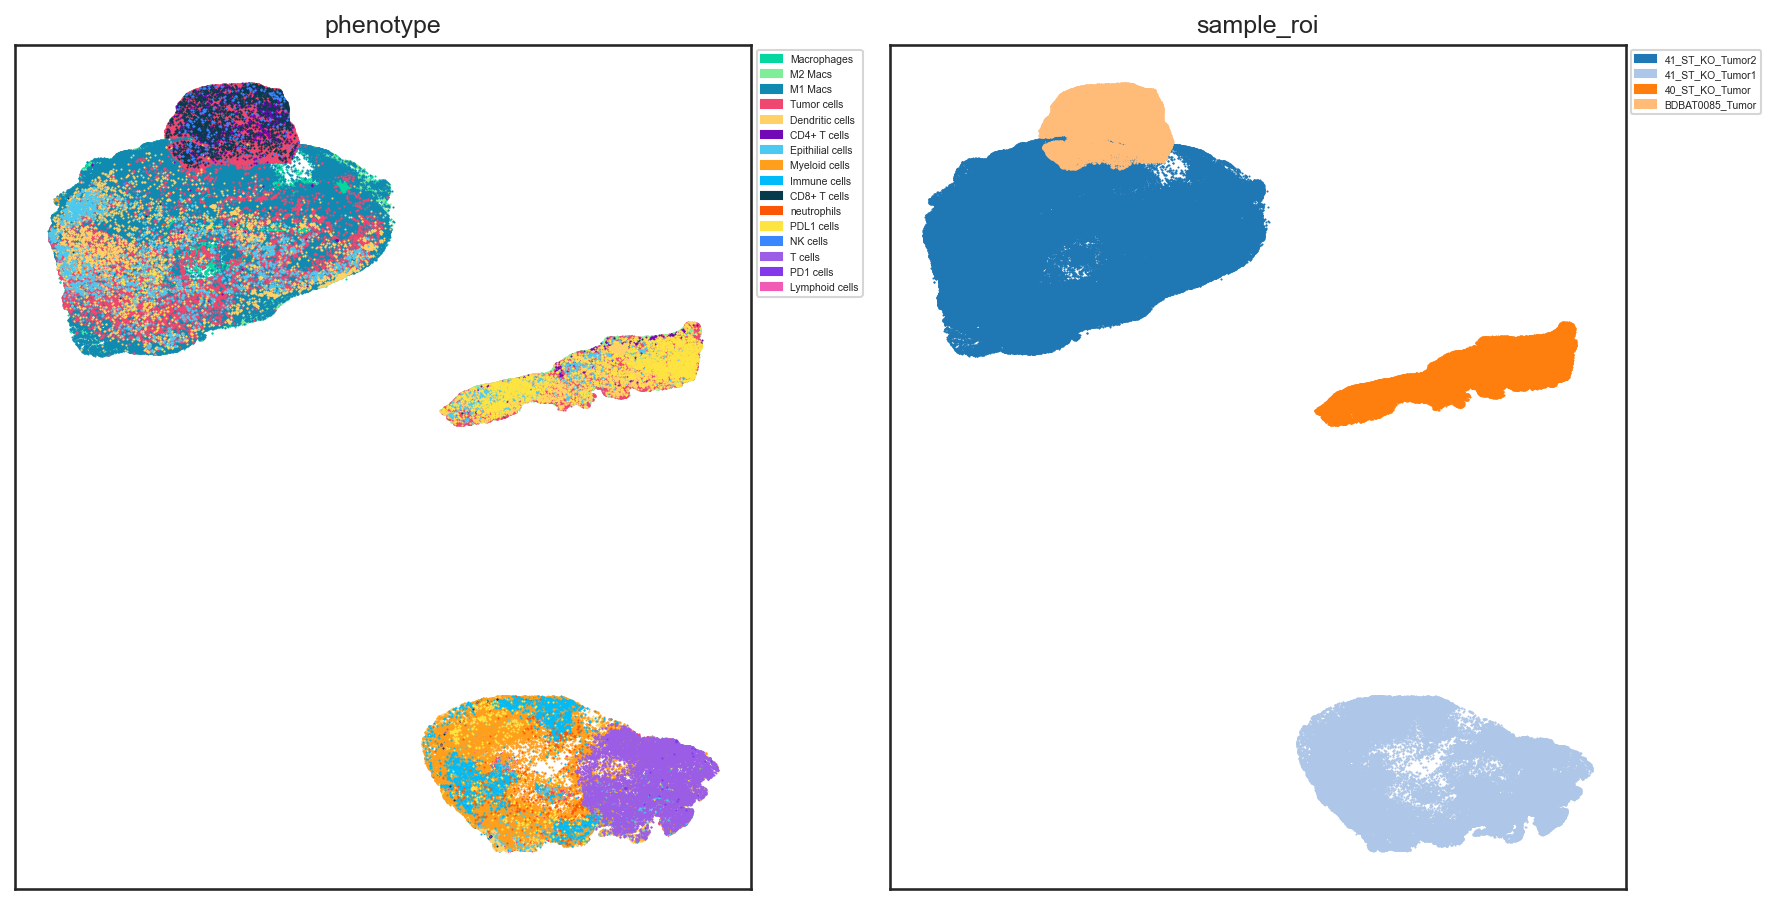

phenotype
M1 Macs             844608
CD4+ T cells        430928
Dendritic cells     351731
M2 Macs             317536
Tumor cells          76904
CD8+ T cells         71622
PDL1 cells           36645
Macrophages          34779
Myeloid cells        23489
Epithilial cells     19005
Lymphoid cells       16307
T cells              11968
Immune cells          3323
NK cells               930
neutrophils            815
PD1 cells               51
Name: count, dtype: int64
sample_roi
40_ST_KO_Spleen    951422
41_ST_KO_Spleen    909485
41_ST_KO_Tumor2    207921
41_ST_KO_Tumor1     85849
40_ST_KO_Tumor      49237
BDBAT0085_Tumor     36727
Name: count, dtype: int64


In [10]:
## Whole tissue scatter plot -- view of the entire tissue colored by cell type + ROI side by side
sm.pl.spatial_scatterPlot( # scimap func, plots cells at their X/Y positions
    adata=adata1,
    colorBy=[phenotype_col, roi_col],# make 2 plots side by side: one colored by cell type, one by ROI
    figsize=(12, 12),
    s=1, # dot size -- small here
    plotLegend=True, # show color legend
    fontsize=5,
    dpi=150,
    customColors=customColors # use our defined color names
)

print(adata.obs[phenotype_col].value_counts())
print(adata.obs[roi_col].value_counts())

--40_ST_KO_Tumor--


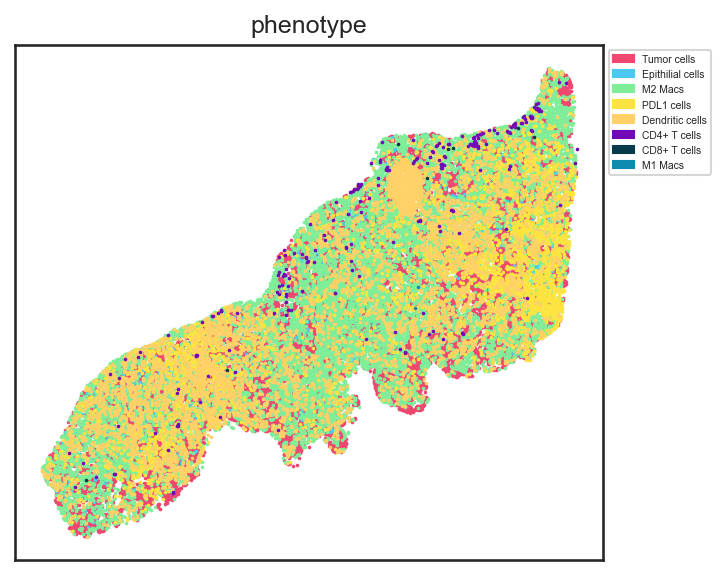

--41_ST_KO_Tumor1--


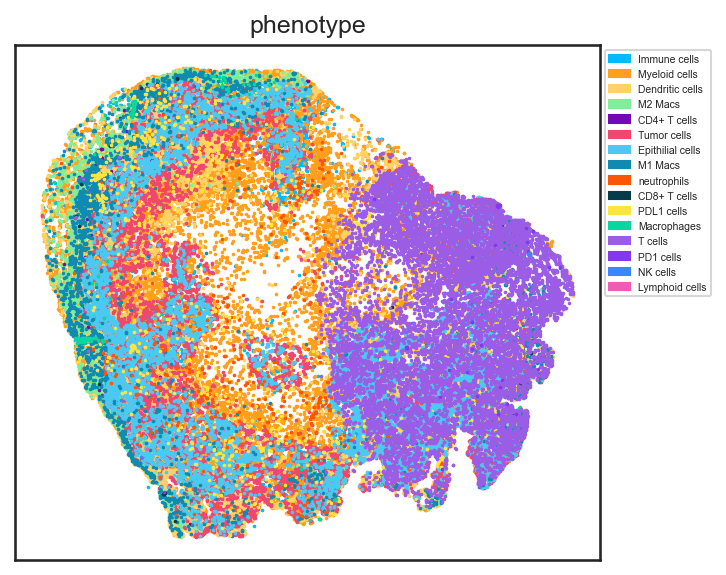

--41_ST_KO_Tumor2--


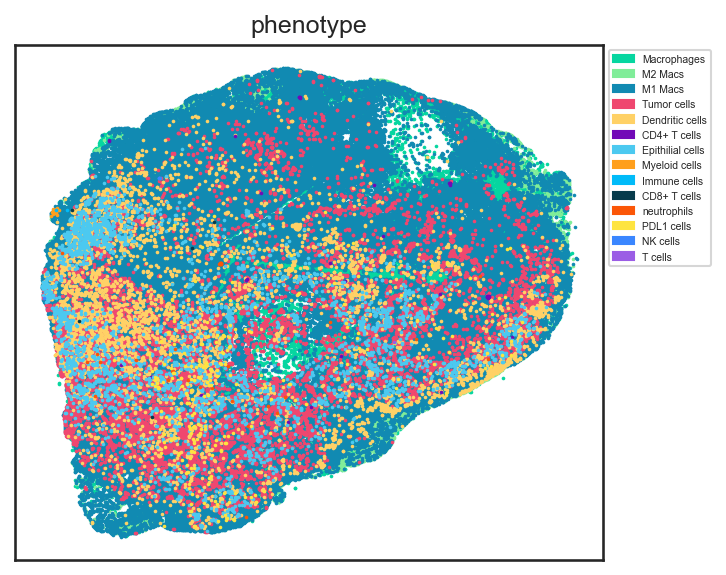

--BDBAT0085_Tumor--


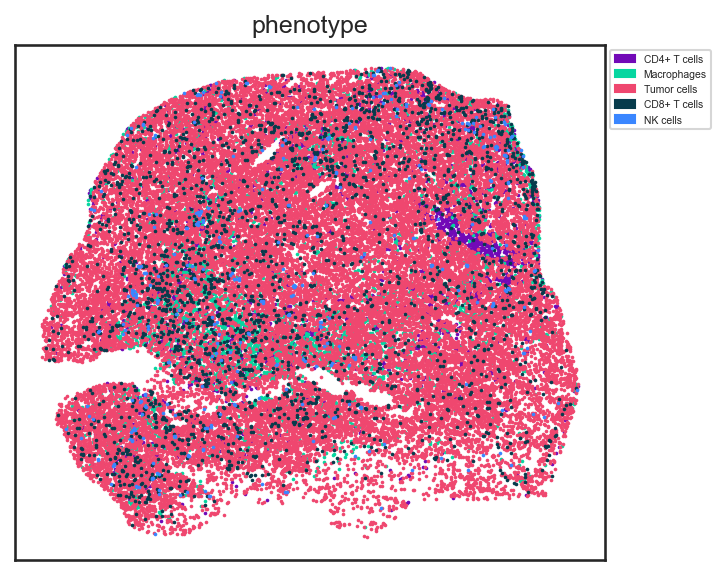

In [11]:
## Same scatter but zoomed into each ROI individually, useful for comparing immune composition between tissue regions 
for roi in rois_to_use:  # loop through each ROI one at a time
    print(f'--{roi}--')
    sm.pl.spatial_scatterPlot(
        adata=adata1,
        colorBy=[phenotype_col],
        imageid=roi_col, # tells scimap the ROI column defines separate images
        subset=roi, # only plot THIS one ROI
        figsize=(5, 4),
        s=3,
        plotLegend=True,
        fontsize=5,
        dpi=150,
        customColors=customColors
    )

In [12]:
## Foldchange, part 1
# First compute the foldchange -- this scimap func looks at how many cells of each type are in each ROI
# and computes log2 fold change compared to the ref ROI (foldchange_from)
# Also runs a Fisher's exact test per cell type to see if the difference
# is statistically significant, then corrects for multiple comparisons

print('foldchange_from set to:', repr(foldchange_from))
print('Actual regions in adata1:', sorted(adata1.obs[roi_col].unique()))
print('Match found:', foldchange_from in adata1.obs[roi_col].unique())
adata1 = sm.tl.foldchange(
    adata1,
    from_group=foldchange_from,  # the reference ROI to compare everything against
    to_group=foldchange_to,  
    imageid=roi_col, # column that identifies the ROIs 
    phenotype=phenotype_col, # column w/ the cell type labels 
    normalize=True,  # normalize cell counts by total cells in each ROI
                     # important b/c without this a bigger ROI would always look like it has more cells 
                     # normalization makes ROIs comparable regarldess of size
    label=foldchange_label # where to store results inside adata1
)

print('Foldchange computed!')
print(f'Results stored in adata1.uns["{foldchange_label}"]')


foldchange_from set to: '41_ST_KO_Tumor1'
Actual regions in adata1: ['40_ST_KO_Tumor', '41_ST_KO_Tumor1', '41_ST_KO_Tumor2', 'BDBAT0085_Tumor']
Match found: True
calculating foldchange
calculating P values
Foldchange computed!
Results stored in adata1.uns["foldchange_roi"]


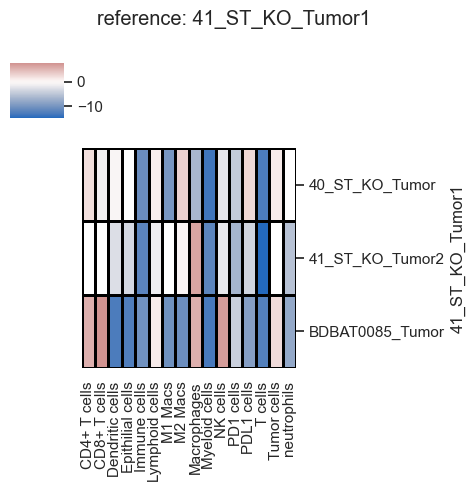

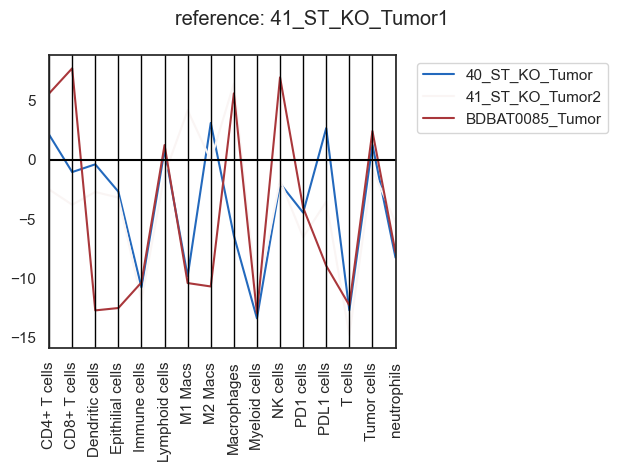

In [13]:
# Foldchange, part 2: plot as a heatmap 
# each row is one cell type, each column is one ROI being compared to the ref ROI
# color = log2 fold change:
# red means this cell type is more abundant in that ROI vs ref and blue means less
# grey means the difference is not statistically significant 
sm.pl.foldchange(
    adata1,
    label=foldchange_label,  # which stored result to plot (must match label above)
    method='heatmap', # display as a heatmap (alternative: 'parallel_coordinates', shown as example on scimap website)
    p_val=0.05,  # significance threshold 
    nonsig_color='grey',   # color for not significant cells in the heatmap
    log=True, # plot log2 fold change 
    figsize=(5, 5),          
    linecolor='black',        
    linewidths=1,
    row_cluster=False,
    col_cluster=False # set these to true if you have 3+ ROIs, otherwise the dendrogram (clutsering) won't work
)

sm.pl.foldchange(
    adata1,
    label=foldchange_label,  # which stored result to plot (must match label above)
    method='parallel_coordinates', # alternate plot type
    p_val=0.05,  # significance threshold 
    nonsig_color='grey',   # color for not significant cells in the heatmap
    log=True # plot log2 fold change         
)

In [41]:
## Scimap spatial interaction
# Computed by comparing real neighbor counts to 1000 random permutations; runs separately for each ROI so can take a few mins
adata1 = sm.tl.spatial_interaction( # tests if cell types neighbor each other more/less than chance
    adata1,
    method='radius', #define neighbors by distance (versus 'knn' which is a fixed number of neighbors)
    radius=interaction_radius, # what we defined as "neighbor" distance
    imageid=roi_col, 
    phenotype=phenotype_col,
    label='spatial_interaction_radius' #name to store the results under in adata1
)

Processing Image: ['41_ST_KO_Tumor2']
Identifying neighbours within 76.9 pixels of every cell
Mapping phenotype to neighbors
Performing 1000 permutations


KeyboardInterrupt: 

In [ ]:
## Plot the results from the previous cell
# Red --> 2 cell types neighbor each other more than chance
# Blue --> they neighbor each other less than chance
# Grey --> no significant relationship
# Each column is 1 ROI, compare patterns across ROIs

sm.pl.spatial_interaction(
    adata1,
    spatial_interaction='spatial_interaction_radius',
    yticklabels=True, # show the cell pair labels on the y axis
    figsize=(6, 8),
    row_cluster=True, # group rows with similar patterns together
    summarize_plot=False, # show each ROI separately instead of averaging 
    linewidths=0.75,
    linecolor='black'
)

In [14]:
## Compute spatial distances 
# For each cell in the dataset, this finds the nearest cell of each OTHER type
# Results are stored inside adata1 for plotting below

adata1 = sm.tl.spatial_distance(
    adata1,
    x_coordinate='X_centroid',  
    y_coordinate='Y_centroid',   
    phenotype=phenotype_col,     
    imageid=roi_col, # column identifying the ROI -- runs separately per ROI so we can compare distances across ROIs
    label='spatial_distance' # name to store results under in adata1
)

print('Spatial distances computed!')
print('Results stored in adata1.uns["spatial_distance"]')

Processing Image: 41_ST_KO_Tumor2
Processing Image: 41_ST_KO_Tumor1
Processing Image: 40_ST_KO_Tumor
Processing Image: BDBAT0085_Tumor
Spatial distances computed!
Results stored in adata1.uns["spatial_distance"]


In [43]:
# Get the ROI for each cell
spatial_dist_df = adata1.uns['spatial_distance'].copy()
spatial_dist_df['ROI'] = adata1.obs[roi_col].values

# Now group by ROI and describe
#spatial_dist_df.groupby('ROI').describe()

spatial_dist_df.groupby('ROI').mean()

print(adata1.obs[roi_col].unique())

['41_ST_KO_Tumor2' '41_ST_KO_Tumor1' '40_ST_KO_Tumor' 'BDBAT0085_Tumor']


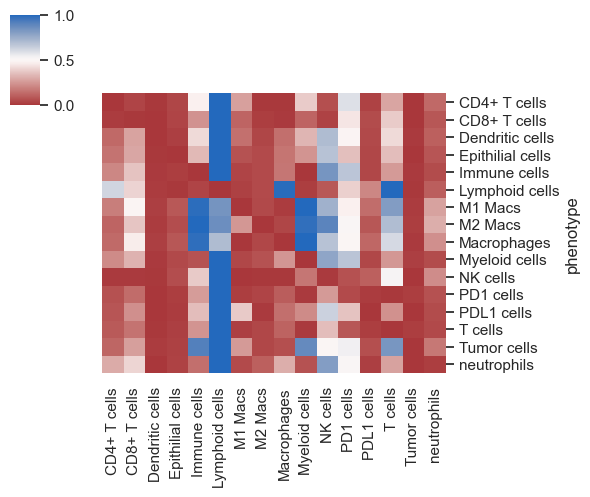


=== 41_ST_KO_Tumor2 ===


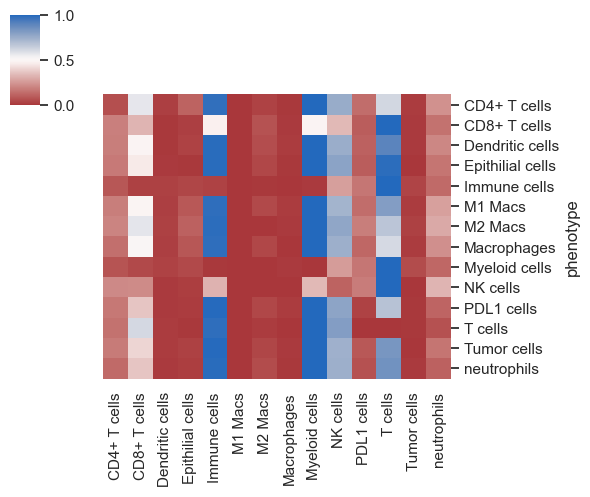


=== 41_ST_KO_Tumor1 ===


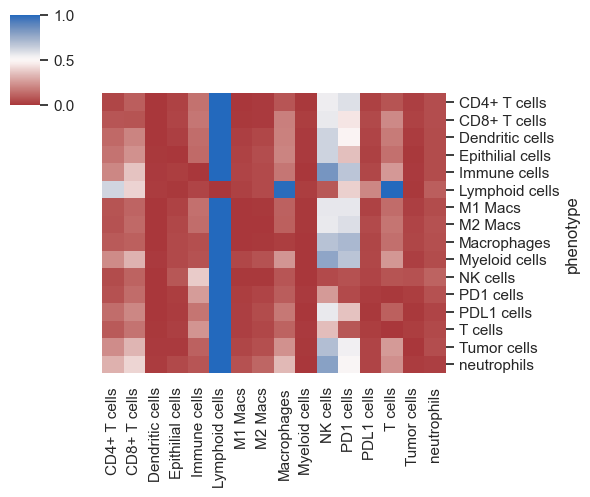


=== 40_ST_KO_Tumor ===


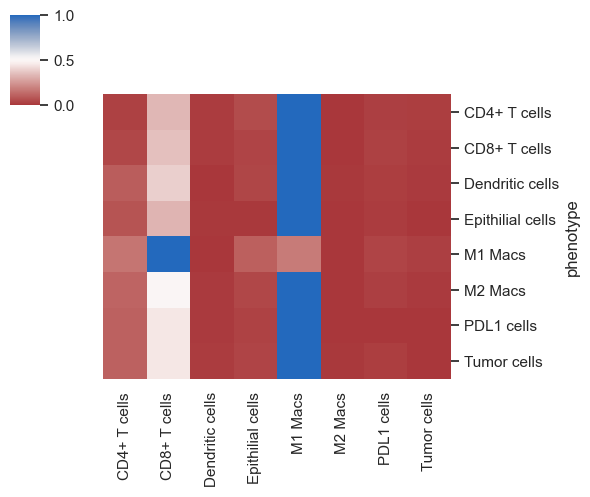


=== BDBAT0085_Tumor ===


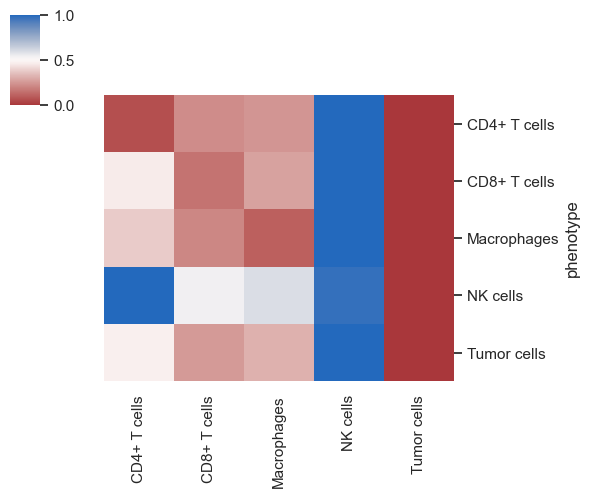

In [44]:
## Heatmap of all pairwise distances 
# Shows the average distance between every pair of cell types at once
# Each grid cell represents the avg distance in pixels between the row type and column type
# Red is closer together, blue is farther
# Quick overview, use to spot which cell types are generally close to or far from each other before looking at details

sm.pl.spatial_distance(
    adata1,
    method='heatmap', # show as a heatmap (all pairs at once)
    imageid=roi_col,            
    label='spatial_distance', # which stored result to use
    figsize=(6, 5)              
)

# Get unique ROIs
rois = adata1.obs[roi_col].unique()

# Plot each ROI separately
for roi in adata1.obs[roi_col].unique():
    adata_roi = adata1[adata1.obs[roi_col] == roi]
    print(f"\n=== {roi} ===")
    sm.pl.spatial_distance(
        adata_roi,
        method='heatmap',
        label='spatial_distance',
        figsize=(6, 5)
    )


--Distance to neutrophils--


<Figure size 1000x400 with 0 Axes>

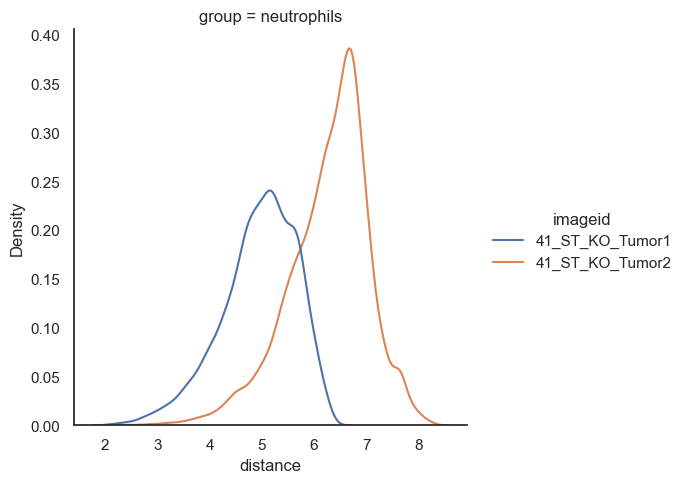

<Figure size 1000x400 with 0 Axes>


--Distance to PDL1 cells--


<Figure size 1000x400 with 0 Axes>

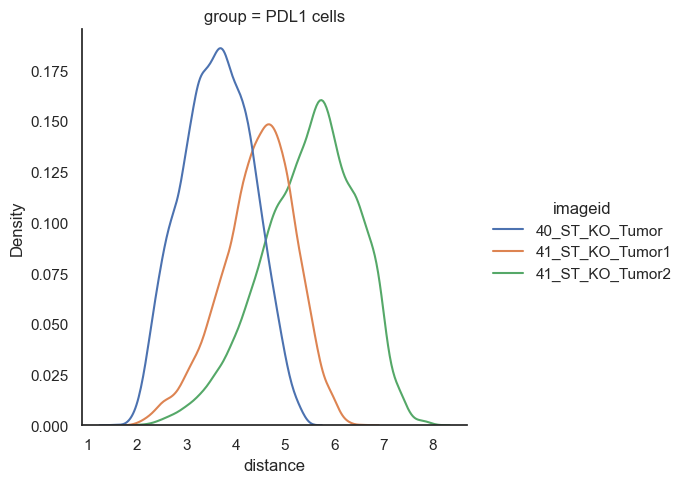

<Figure size 1000x400 with 0 Axes>


--Distance to PD1 cells--


<Figure size 1000x400 with 0 Axes>

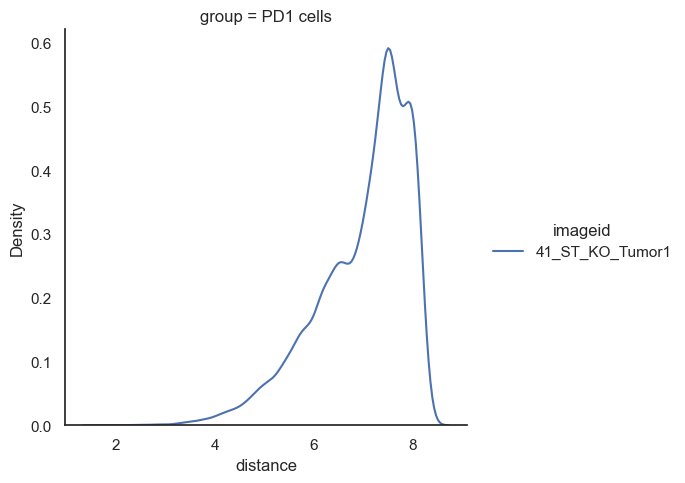

<Figure size 1000x400 with 0 Axes>


--Distance to M2 Macs--


<Figure size 1000x400 with 0 Axes>

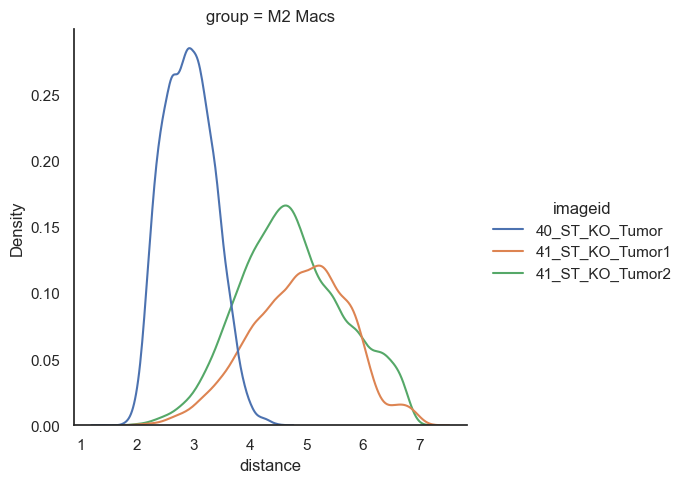

<Figure size 1000x400 with 0 Axes>


--Distance to M1 Macs--


<Figure size 1000x400 with 0 Axes>

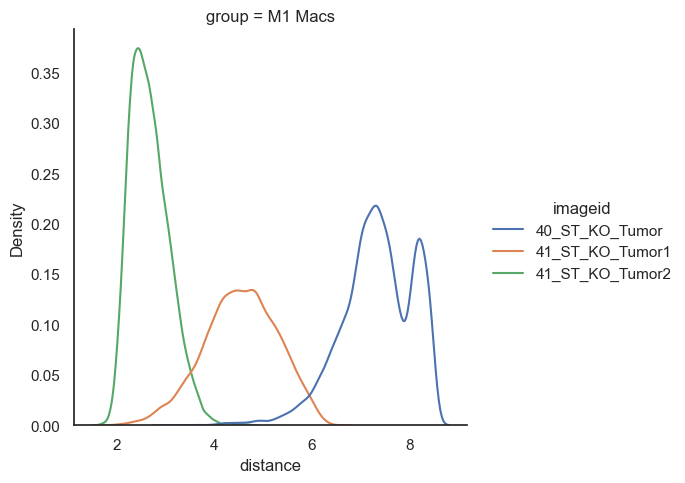

<Figure size 1000x400 with 0 Axes>


--Distance to Epithilial cells--


<Figure size 1000x400 with 0 Axes>

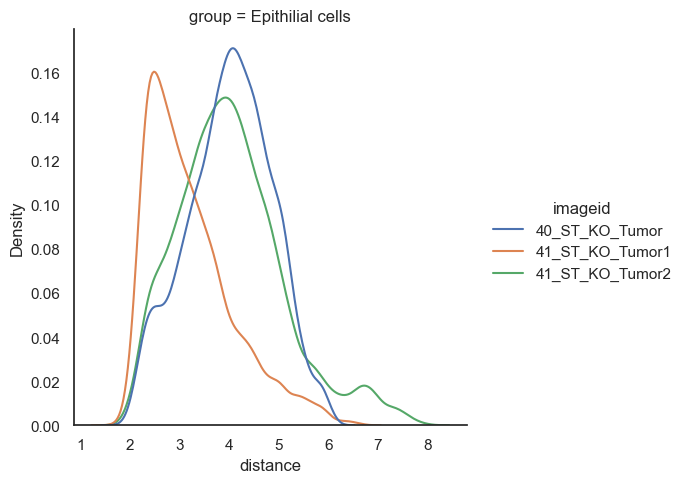

<Figure size 1000x400 with 0 Axes>


--Distance to Dendritic cells--


<Figure size 1000x400 with 0 Axes>

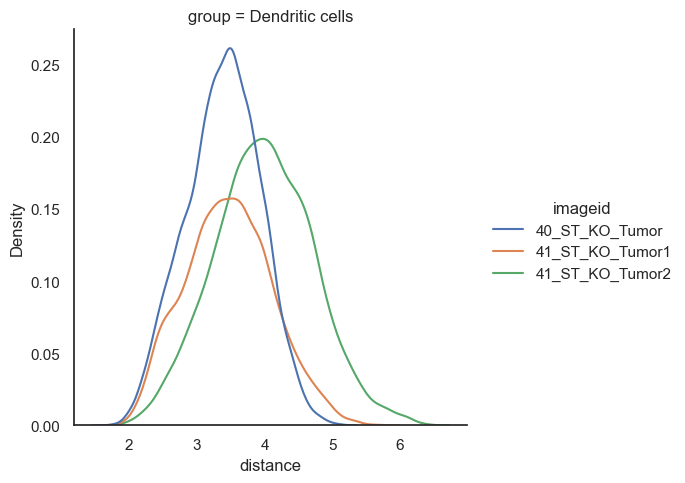

<Figure size 1000x400 with 0 Axes>


--Distance to CD8+ T cells--


<Figure size 1000x400 with 0 Axes>

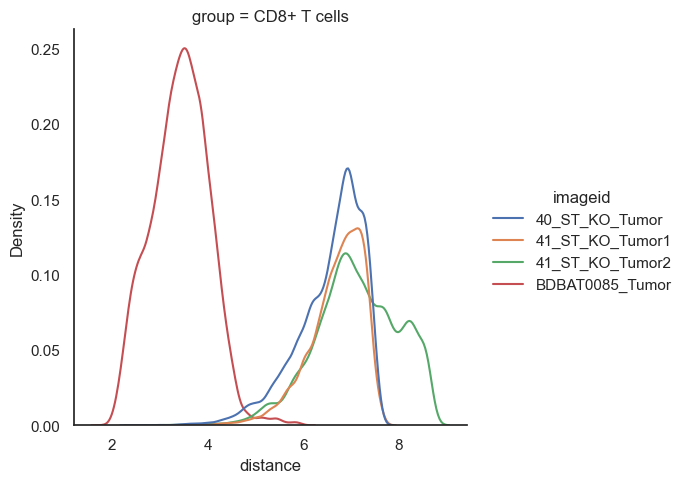

<Figure size 1000x400 with 0 Axes>


--Distance to CD4+ T cells--


<Figure size 1000x400 with 0 Axes>

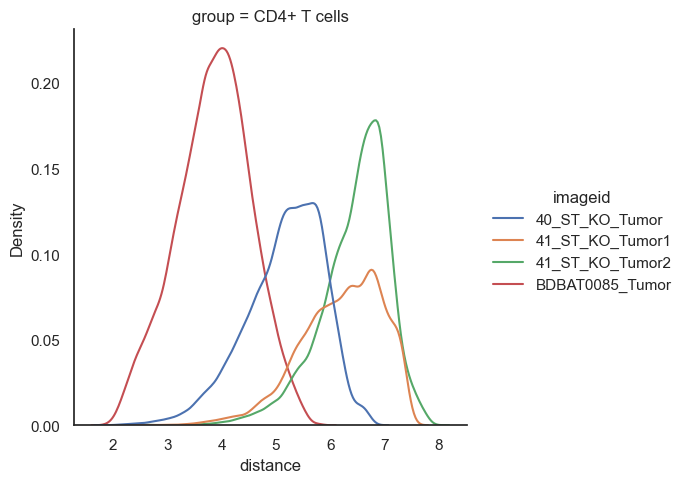

<Figure size 1000x400 with 0 Axes>

In [45]:
## Distribution plots of distance from each immune cell type to nearest tumor cell 
# 1 plot per immune cell type in distance_to
# Within each plot, split by ROI so you can compare across regions

for cell_type in distance_to:  # loop through each cell type one at a time -- so each plot is clear even when we have many cell types
    print(f"\n--Distance to {cell_type}--")

    fig = plt.figure(figsize=(10, 4))  # set figure size before calling scimap
    sm.pl.spatial_distance(
        adata1,
        method='distribution',   # show as distribution plots
        distance_from=distance_from,  # measure FROM this cell type
        distance_to=[cell_type],  # only this cell type
        imageid=roi_col, # split each violin by ROI
        label='spatial_distance',  # which stored result to use
        log=True, # log scale on the distance axis bc distance span a wide range
    )




    plt.gcf().set_size_inches(10, 4)
    plt.show()


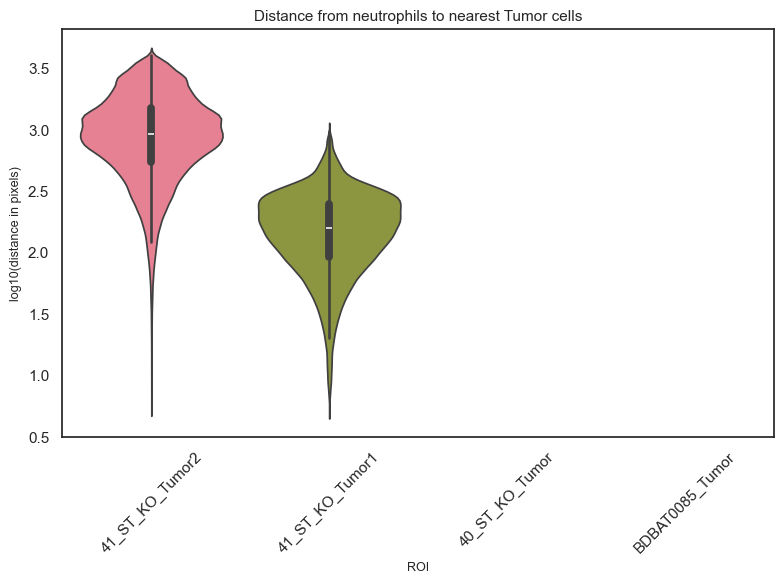

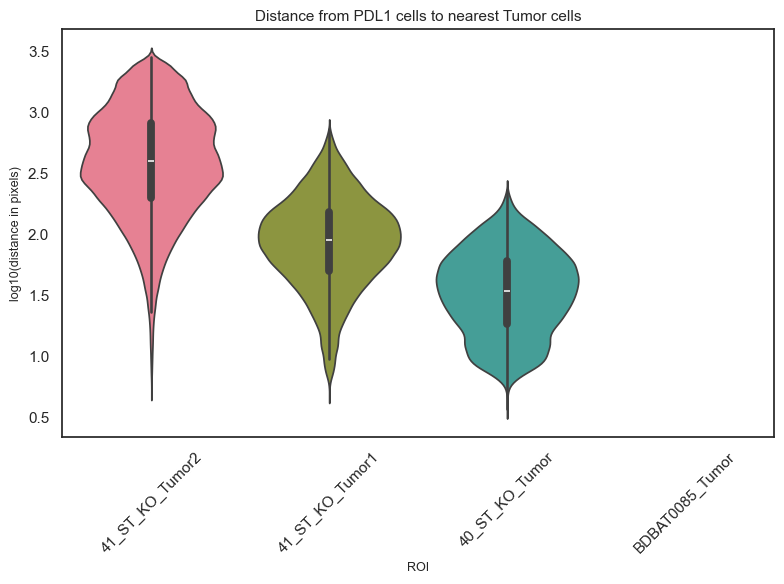

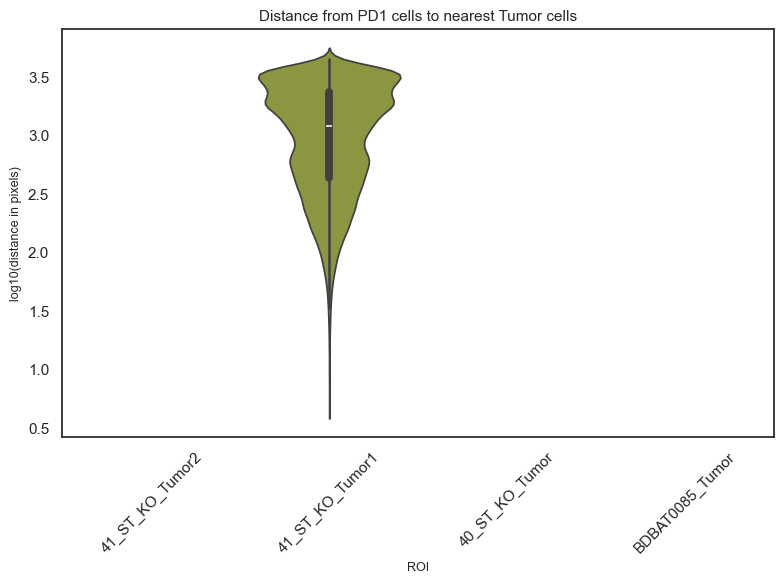

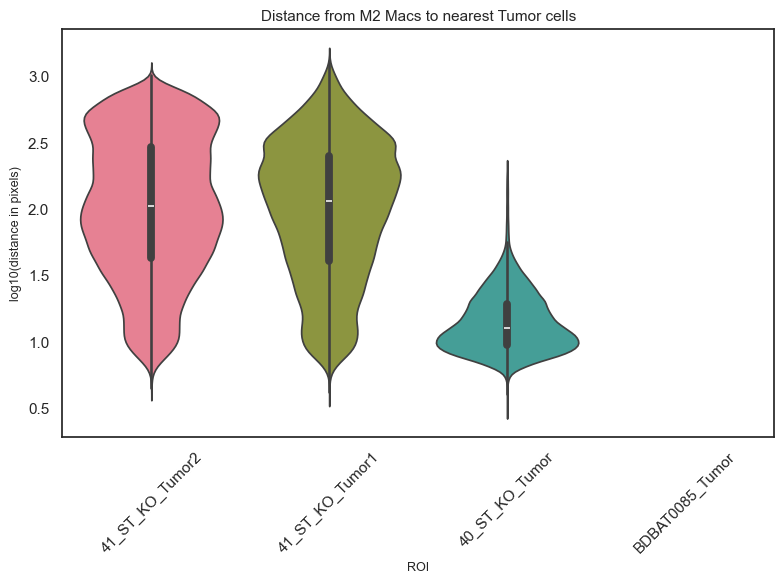

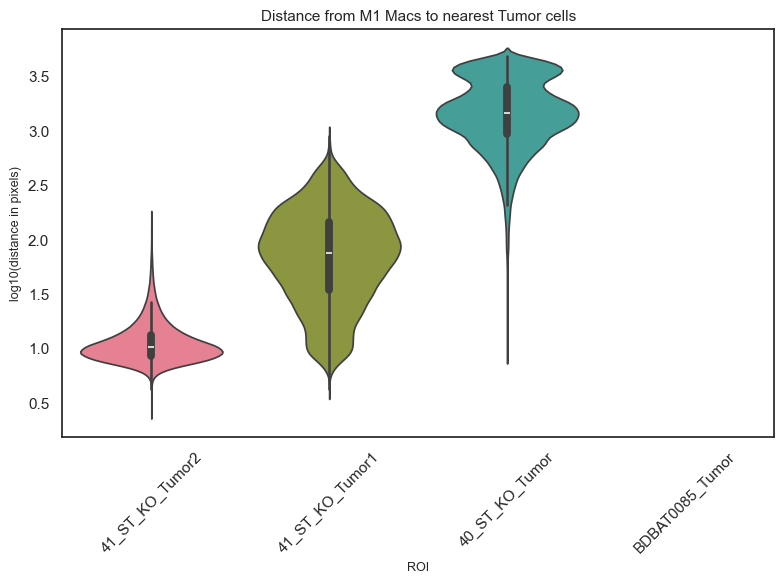

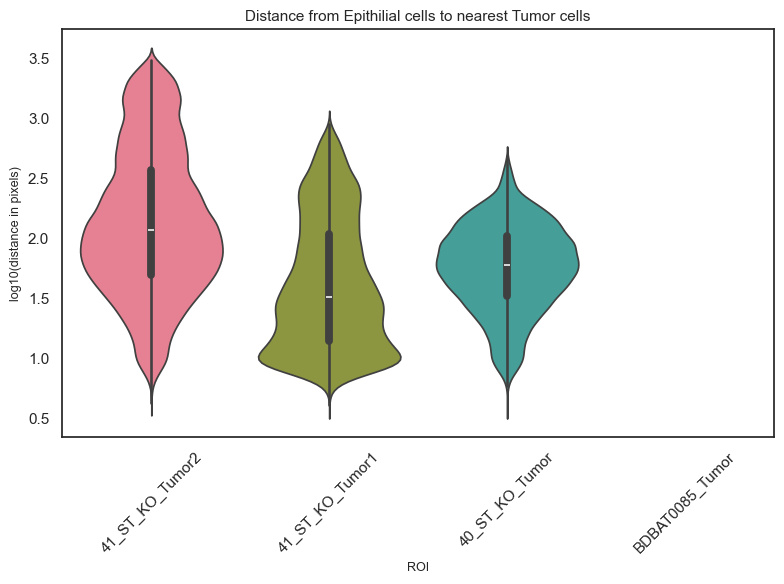

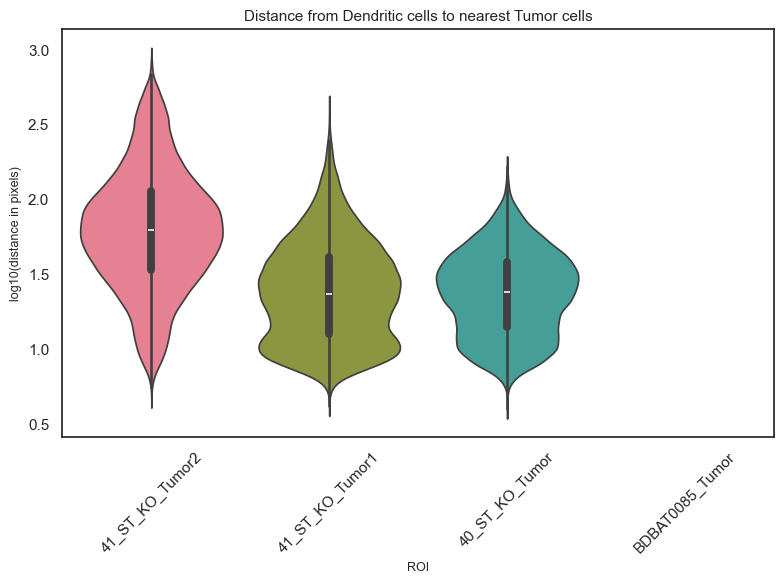

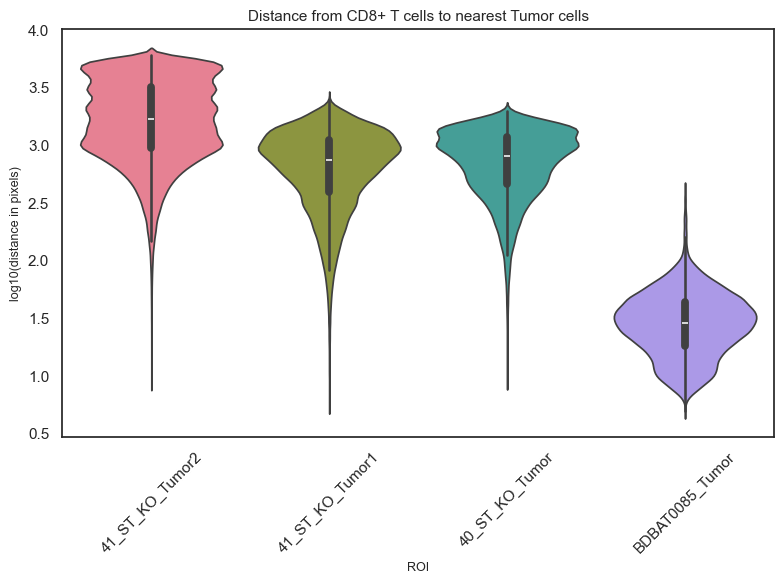

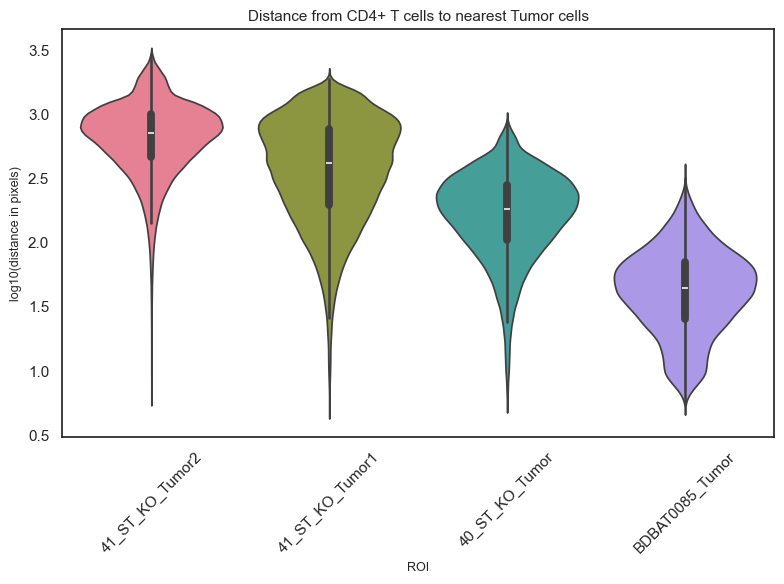

In [46]:
## Violin plots of spatial distances
# Pull the distance table out of adata1, where one row = one cell and one column per cell type showing distance to nearest
# cell of that type

dist_data = adata1.uns['spatial_distance'].copy()   # work on a copy

# add ROI column by looking up each cell's ROI label from adata1.obs
# dist_data.index contains the cell IDs and we use those to look up the matching ROI 
dist_data['ROI'] = adata1.obs.loc[dist_data.index, roi_col]

# Need to reshape from wide to long format because seaborn (use to make the plots) needs this
# wide is one row per cell, one column per cell type 
# long is one row per (cell + cell type) combo
dist_long = dist_data[distance_to + ['ROI']].melt(
    id_vars='ROI',  # keep ROI as an identifier column, don't need to reshape this one
    var_name='cell_type', # the column names (CD8+ T cells etc) are now going to be values in this new column
    value_name='distance' # the actual distance numbers will now go into this column
)

# Force the distances to be numeric 
# scimap sometimes stores distances as categorical data type (a lookup table) instead of numbers

dist_long['distance'] = pd.to_numeric(dist_long['distance'], errors='coerce')

# Log transform the distances (They span a wide range)
dist_long['log_distance'] = np.log10(dist_long['distance'])

# One subplot per immune cell type 
# within each subplot we have one violin per ROI

for cell_type in distance_to:  # loop through each immune cell type, one full figure per type (clear even w/ many cell types)
    fig, ax = plt.subplots(figsize=(8, 6))  # one full width figure per cell type
    # filter to only the rows for this specific cell type
    subset = dist_long[dist_long['cell_type'] == cell_type]
    sns.violinplot(
        data=subset,
        x='ROI',
        y='log_distance',
        inner='box',
        ax=ax,
        hue='ROI',
        palette='husl'
    )
    ax.set_title(f'Distance from {cell_type} to nearest {distance_from}', fontsize=11)
    ax.set_xlabel('ROI', fontsize=9)
    ax.set_ylabel('log10(distance in pixels)', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

In [47]:
# Custom func to compute raw pairwise interaction counts using scipy, different from the scimap version above 
# this one counts actual occurrences -- for each cell, how many neighbors of each cell type fall within the radius

def spatial_interaction_working(adata, radius=interaction_radius, phenotype_col='phenotype', imageid_col='ROI'):
    """
    Purpose
    -------
    Count raw pairwise cell type interactions within a radius for each ROI

    Parameters
    ----------
    adata : AnnData
        The dataset, must have "X_centroid" and "Y_centroid" in adata.obs
    radius : int
        Neighbor search distance in pixels
    phenotype_col : str
        Name of the obs column w/ cell type labels
    imageid_col : str
        Name of the obs column that separates regions

    Returns
    -------
    pd.DataFrame
        One row per (ROI, cell type, neighbor cell type) w/ an interaction count
    """

    
    print('Starting spatial interaction analysis...')
    all_results = [] # empty list to collect results

    for roi in adata.obs[imageid_col].unique(): # loop over each unique ROI
        if roi == 'Other': # skip cells outside any ROI -- should be fine, this is another safety net
            continue                                    
        print(f'Processing {roi}...')            

        roi_data = adata[adata.obs[imageid_col] == roi].copy() # subset to just this ROI (independent copy)
        if len(roi_data) < 2: # need at least 2 cells to have a pair (safety check)
            continue  

        coords = np.array([  # build an array of positions -- 2 rows x (number of cells) columns
            roi_data.obs['X_centroid'].values,  # all x positions
            roi_data.obs['Y_centroid'].values  # all y positions
        ]).T.astype(np.float64)  # .T flips it to rows=cells

        phenotypes = roi_data.obs[phenotype_col].values  # cell type label for each cell, same order as coords

        distances = cdist(coords, coords, metric='euclidean')  # compute the distance between every possible pair of cells
                                                               # get a big matrix with all those distances, n x n

        interaction_counts = {}  # dict for counting
        for i in range(len(coords)): # loop over every cell as the "center" cell
            neighbor_mask = (distances[i] <= radius) & (np.arange(len(coords)) != i)  # True for cells within radius AND not itself
            for j in np.where(neighbor_mask)[0]: # loop over the indices of those neighbors (the indices that were True)
                key = (roi, phenotypes[i], phenotypes[j])# tuple --> (this ROI, center cell type, neighbor cell type)
                interaction_counts[key] = interaction_counts.get(key, 0) + 1  # look up current count for this key
                                                                              # return 0 if this key (cell type pair) has never been seen 
                                                                              # add 1 to that pair's count

        for (roi_name, pheno1, pheno2), count in interaction_counts.items():  # unpack each cell neighbor pair 
            all_results.append({  # add a row to our results list
                'ROI': roi_name,
                'phenotype': pheno1,
                'neighbor_phenotype': pheno2,
                'interaction_count': count
            })
        print(f'{roi} done!')                 

    results_df = pd.DataFrame(all_results) # turn the list of dicts into a dataframe
    print(f'\nComplete! {len(results_df)} interaction pairs found')  
    return results_df  
    

print(f"Function 'spatial_interaction_working' defined")

Function 'spatial_interaction_working' defined


In [ ]:
# Here we actually run the raw counts function
spatial_results = spatial_interaction_working(
    adata1,
    radius=interaction_radius,
    phenotype_col=phenotype_col,
    imageid_col=roi_col
)

Starting spatial interaction analysis...
Processing 41_ST_KO_Tumor2...


In [ ]:
# One heatmap per ROI showing the raw interaction counts between every cell type pair
# Each grid cell is how many times the row type was found within the radius of column type
# Compare across ROIs!


rois_in_results = spatial_results['ROI'].unique()  # list of ROIs that produced results
fig, axes = plt.subplots(1, len(rois_in_results), # one subplot column (panel) per ROI
                         figsize=(6 * len(rois_in_results), 6)) #  scale width by number of ROIs
if len(rois_in_results) == 1:  # matplotlib quirk that 1 subplot isn't a list
    axes = [axes]

for i, roi in enumerate(rois_in_results): # loop over each ROI with its index i
    roi_data = spatial_results[spatial_results['ROI'] == roi] # rows for just this ROI from spatial_results
    matrix = roi_data.pivot(  # reshape long table into a grid
        index='phenotype',# rows --> center cell type
        columns='neighbor_phenotype', # columns --> neighbor cell type
        values='interaction_count' #grid values --> counts
    ).fillna(0)

    sns.heatmap( # draw the heatmap
        matrix,
        annot=True, fmt='.0f', # write number in each cell, no decimals
        cmap='Blues',     
        linewidths=0.75, linecolor='black',             
        ax=axes[i], # draw on the ith subplot
        cbar_kws={'label': 'Interaction Count'} # colorbar label
    )
    axes[i].set_title(f'{roi} — Raw Interaction Counts\n(radius={interaction_radius}px)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Left shows the total interactions per cell type per ROI
# Right shows neighbor diversity -- so how many DIFFERENT cell types does each type interact with

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # two subplots side by side

summary = (spatial_results  # start from the results table
           .groupby(['ROI', 'phenotype'])  # group rows by ROI and cell type
           ['interaction_count']  # we care about the count column
           .sum()   # total interactions per group
           .reset_index())  # turn the grouped result back into a flat table

sns.barplot(data=summary, x='phenotype', y='interaction_count',  # bar plot of totals
            hue='ROI', ax=ax1)     # one bar color per ROI, draw on left subplot
ax1.set_title('Total Interactions by Cell Type')  
ax1.set_xlabel('Cell Type')                           
ax1.set_ylabel('Total Interaction Count')           
ax1.tick_params(axis='x', rotation=45)   # rotate labels

diversity = (spatial_results    # start from results again
             .groupby(['ROI', 'phenotype'])   # group by ROI and cell type
             ['neighbor_phenotype']  # look at the neighbor type column
             .nunique()   # count how many DIFFERENT neighbor types
             .reset_index()) # flatten back to a table

diversity.columns = ['ROI', 'phenotype', 'neighbor_diversity']  # rename for clarity
sns.barplot(data=diversity, x='phenotype', y='neighbor_diversity',  # bar plot of diversity
            hue='ROI', ax=ax2)  

ax2.set_title('Neighbor Diversity by Cell Type')       
ax2.set_xlabel('Cell Type')                          
ax2.set_ylabel('Number of Different Neighbor Types')    
ax2.tick_params(axis='x', rotation=45)                  

plt.tight_layout()
plt.show()

Plotting voronoi for 41_ST_KO_Tumor1: 85,849 cells


KeyboardInterrupt: 

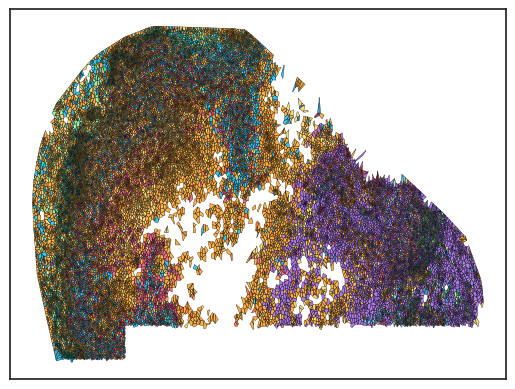

In [22]:
## Voronoi tissue map: every cell gets drawn as a colored polygon instead of just a dot

# Subset to the chosen ROI
adata_roi = adata1[adata1.obs[roi_col] == voronoi_roi].copy() # boolean mask: keep only cells in this ROI + work on a copy
                                                              
print(f'Plotting voronoi for {voronoi_roi}: {adata_roi.n_obs:,} cells')

# Run scimap voronoi and save directly to a file 
# Here we save to a file instead of displaying because scimap always opens its own figure internally 
# if we just call plt.show() the legend ends up on a separate empty plot
sm.pl.voronoi(
    adata_roi,
    color_by=phenotype_col, # color by cell type
    voronoi_edge_color='black',  # thin black border between polygons
    voronoi_line_width=0.3,  
    voronoi_alpha=0.8, # polygon opacity
    size_max=voronoi_size_max, # maximum area any single polygon is allowed to be
    overlay_points=None, # don't draw dots on top of polygons (cleaner)
    plot_legend=False, # turn OFF scimap's built-in legend, draw our own below
    legend_size=6,
    colors=customColors, # use our defined colors
    saveDir=voronoi_save_dir, # folder to save the image to
    fileName=voronoi_filename # filename for the saved image
)
#  define the actual (final) path name after scimap saves the image
voronoi_actual_path = os.path.join(voronoi_save_dir, voronoi_filename)

# Now, we reload the saved image and add our legend on top 
# Here we get full control of the figure because we make it ourselves with plt.subplots()
# scimap's figure is gone, we're working with a flat image loaded from where we saved it

# Load from that path
img = Image.open(voronoi_actual_path)

fig, ax = plt.subplots(figsize=(12, 12), dpi=200)  # create our own high res figure
                                                
ax.imshow(img) # draw the voronoi image onto our axes
ax.set_xticks([]) # hide x axis tick marks 
ax.set_yticks([]) # hide y-axis tick marks

# Finally build and add the legend manually 
# mpatches.Patch makes one colored rectangle per cell type
# Filter to only include cell types that actually exist in this ROI
legend_patches = [
    mpatches.Patch(color=color, label=cell_type)           # colored square + label
    for cell_type, color in customColors.items()           # loop through all defined colors
    if cell_type in adata_roi.obs[phenotype_col].values    # only include if present in this ROI
]

ax.legend(
    handles=legend_patches,  # the list of colored squares we just built
    loc='upper right',  # position on the plot
    fontsize=11,              
    framealpha=0.9, # legend box background opacity 
    title='Cell Type',      
    title_fontsize=12       
)

plt.tight_layout() # auto adjust spacing so nothing gets cut off
plt.show()          

In [23]:
## First, find dense spatial clusters of each cell type 
# Looks at every cell and checks what fraction of its neighbors are the same cell type as itself
# If that fraction is >= aggregate_purity then the cell gets labeled with its cell type as a "pure aggregate" region
# If the fraction is below --> gets labeled "other" meaning it's in a mixed region 

adata1 = sm.tl.spatial_aggregate(
    adata1,
    phenotype=phenotype_col,  # column w/ cell type labels
    method='radius',  # define neighborhood by distance
    radius=aggregate_radius,   
    purity=aggregate_purity,    
    imageid=roi_col, # run separately per ROI
    label=aggregate_label # name of the new column added 
)

print('Spatial aggregation complete!')
print(f'New column "{aggregate_label}" added to adata1.obs')
print('\nAggregate region counts:')
print(adata1.obs[aggregate_label].value_counts())


Identifying neighbours within 46.2 pixels of every cell
Identifying neighbours within 46.2 pixels of every cell
Identifying neighbours within 46.2 pixels of every cell
Identifying neighbours within 46.2 pixels of every cell
Spatial aggregation complete!
New column "spatial_aggregate" added to adata1.obs

Aggregate region counts:
spatial_aggregate
non-significant     263624
M1 Macs              79450
Tumor cells          22606
Myeloid cells         3523
Macrophages           3208
M2 Macs               2849
Dendritic cells       2143
T cells               1683
Epithilial cells       436
CD4+ T cells            98
Immune cells            60
PDL1 cells              36
neutrophils             18
Name: count, dtype: int64


In [ ]:
# Visualize aggregate regions on the same ROI as before 
# same approach as the voronoi cell above but now we color by aggregate_label instead of phenotype
# so instead of seeing individual cell types you see which regions are
# dense clusters vs mixed 

# ‼️Review the types of aggregate regions from the cell output above -- now assign them colors:‼️

agg_voronoi_colors = {
    'non-significant':  '#cccccc',
    'M1 Macs':           '#118ab2',
    'Tumor cells':        '#ef476f',
    'Myeloid cells':      '#ff9f1c',
    'Macrophages':        '#06d6a0',
    'M2 Macs':            '#80ed99',
    'Dendritic cells':    '#ffd166',
    'T cells':            '#9b5de5',
    'Epithilial cells':   '#4cc9f0',
    'CD4+ T cells':       '#7209b7',
    'Immune cells':       '#00bbf9',
    'PDL1 cells':         '#fee440',
    'neutrophils':        '#fb5607'}

# subset to whichever same ROI we used for the phenotype voronoi
adata_roi_agg = adata1[adata1.obs[roi_col] == aggregate_roi].copy()

# save the voronoi colored by aggregate regions
agg_filename = f'voronoi_aggregate_{voronoi_roi}.png'  # separate filename so we don't overwrite the phenotype voronoi

sm.pl.voronoi(
    adata_roi_agg,
    color_by=aggregate_label,   # color by aggregate region, not phenotype
    voronoi_edge_color='facecolor',
    voronoi_line_width=0.3,
    voronoi_alpha=0.8,
    size_max=voronoi_size_max,
    overlay_points=None,
    plot_legend=False,
    legend_size=6,
    colors=agg_voronoi_colors,
    saveDir=voronoi_save_dir,
    fileName=agg_filename
)

# build the actual path the same way as before
agg_actual_path = os.path.join(voronoi_save_dir, agg_filename)

# reload and add legend same as before
img_agg = Image.open(agg_actual_path)

fig, ax = plt.subplots(figsize=(12, 12), dpi=200)
ax.imshow(img_agg)
ax.set_xticks([])
ax.set_yticks([])

# build legend from the aggregate labels that actually exist in this ROI
legend_patches = [
    mpatches.Patch(color=color, label=label)
    for label, color in agg_voronoi_colors.items()
    if label in adata_roi_agg.obs[aggregate_label].values  # mostly same as before
]

ax.legend(handles=legend_patches, loc='upper right',
          fontsize=11, framealpha=0.9,
          title='Aggregate Region', title_fontsize=12)

plt.tight_layout()
plt.show()

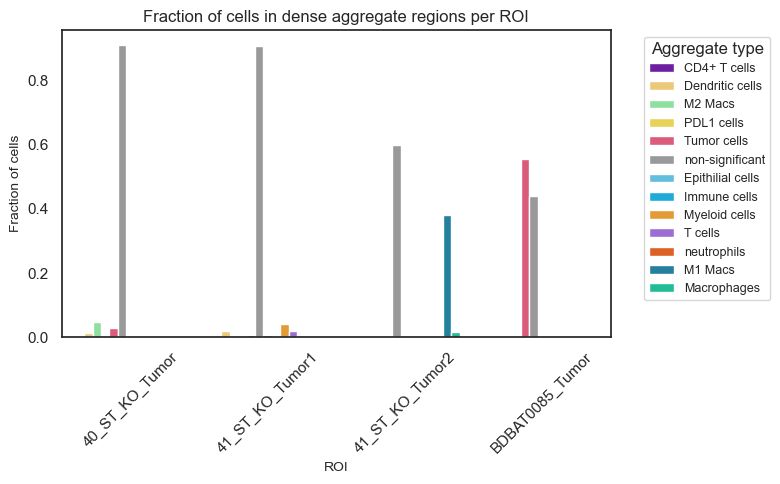

In [25]:
## Here we look at how much of each ROI is dense aggregate vs mixed
# counts what fraction of cells in each ROI fall into a pure aggregate vs the mixed other category
# useful for comparing ROIs

agg_counts = (adata1.obs
              .groupby([roi_col, aggregate_label]) # group by ROI and aggregate label
              .size() # count cells per group
              .reset_index(name='count')) # turn into a flat table

# calculate fraction within each ROI so bars are comparable regardless of raw ROI size
agg_counts['fraction'] = (agg_counts
                          .groupby(roi_col)['count'] # within each ROI
                          .transform(lambda x: x / x.sum())) # lambda func to divide each count by the ROI total

fig, ax = plt.subplots(figsize=(8, 5))

agg_palette = {**customColors, 'non-significant': '#999999'} # use our defined colors bc the default ones are too similar to each other

sns.barplot(
    data=agg_counts,
    x=roi_col, # one group of bars per ROI
    y='fraction',   # height = fraction of cells in this aggregate type
    hue=aggregate_label,  # one bar color per aggregate label
    ax=ax,
    palette = agg_palette
)

ax.set_title('Fraction of cells in dense aggregate regions per ROI', fontsize=12)
ax.set_xlabel('ROI', fontsize=10)
ax.set_ylabel('Fraction of cells', fontsize=10)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Aggregate type', bbox_to_anchor=(1.05, 1),  # legend outside the plot so it doesn't cover the bars
          loc='upper left', fontsize=9)                       

plt.tight_layout()
plt.show()